<a href="https://colab.research.google.com/github/PrakitiPratha/BreastCancerBiomarkers/blob/main/BreastCancerBiomarkers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identification of Breast Cancer Biomarkers: A Hybrid Machine Learning Approach for miRNA-Based Classification

mirna_pipeline_clean_flow.svg

## 1. Environment Setup & Data Loading

This notebook implements a hybrid **PCA → Random Forest → SVM** pipeline for binary classification of patient samples as *Primary Breast Cancer* or *Normal Breast Tissue* using miRNA expression profiles.

All standard scientific Python libraries are imported: `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualisation, and `scikit-learn` for preprocessing, dimensionality reduction, and classification. Stratified K-Fold cross-validation is used throughout to ensure class balance across all evaluation folds.

The dataset is loaded directly from Google Drive. Features (`X_raw`) consist entirely of miRNA expression columns, and the target label (`y_raw`) is the `target_actual` column indicating sample diagnosis.

In [ ]:
from google.colab import drive

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
# Plotting Settings
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="whitegrid")

In [ ]:
drive.mount('/content/drive')
df_full = pd.read_csv("/content/drive/My Drive/project/dataset.csv")

Mounted at /content/drive


In [ ]:
X_raw = df_full.iloc[:, :-2]  # all miRNA columns
y_raw = df_full["target_actual"]   # labels

In [ ]:
print(f"Dataset Loaded: {X_raw.shape[0]} samples and {X_raw.shape[1]} miRNAs.")

Dataset Loaded: 133 samples and 1926 miRNAs.


## 2. Preprocessing & Normalisation

### 2.1 Preprocessing Steps

Raw miRNA expression data requires careful preparation before any modelling. Three sequential steps are applied to the full feature matrix:

1. **Mean imputation** — any missing expression values (`NaN`) are replaced with the column-wise mean, preserving the full sample count without introducing deletion bias.
2. **Log₂(x + 1) transformation** — compresses the wide dynamic range of expression values, stabilises variance across low- and high-expressing miRNAs, and brings distributions closer to normality. The pseudo-count `+1` prevents undefined values where expression is zero.
3. **Z-score standardisation (`StandardScaler`)** — centres each miRNA feature to mean = 0 and standard deviation = 1. This is a hard requirement before PCA (variance-driven) and SVM (distance-driven); without it, high-magnitude features dominate both methods regardless of biological relevance.

In [ ]:
X_filled = X_raw.fillna(X_raw.mean(numeric_only=True))  # Handle missing values - mean use kiye to fill
X_log = np.log2(X_filled + 1)

In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), columns=X_raw.columns)

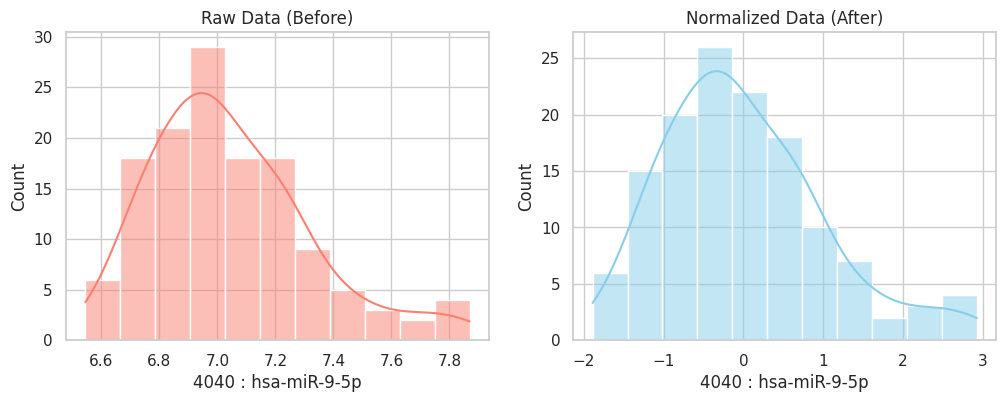

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_raw.iloc[:, 0], kde=True, ax=ax[0], color='salmon').set_title("Raw Data (Before)")
sns.histplot(X_scaled.iloc[:, 0], kde=True, ax=ax[1], color='skyblue').set_title("Normalized Data (After)")
plt.show()

### 2.2 Distribution Before and After Normalisation

The histograms above show the expression distribution of `hsa-miR-9-5p` before and after preprocessing.

**Before (left):** Raw values range from approximately 6.6 to 7.9, showing a mild right skew with a tail toward higher expression values. This uneven spread is typical of microarray-derived miRNA data.

**After (right):** Post-standardisation, the distribution is recentred to mean = 0 and spans roughly −2 to +3, with variance stabilised. The shape is now approximately normal, which satisfies the assumptions of downstream PCA and SVM.

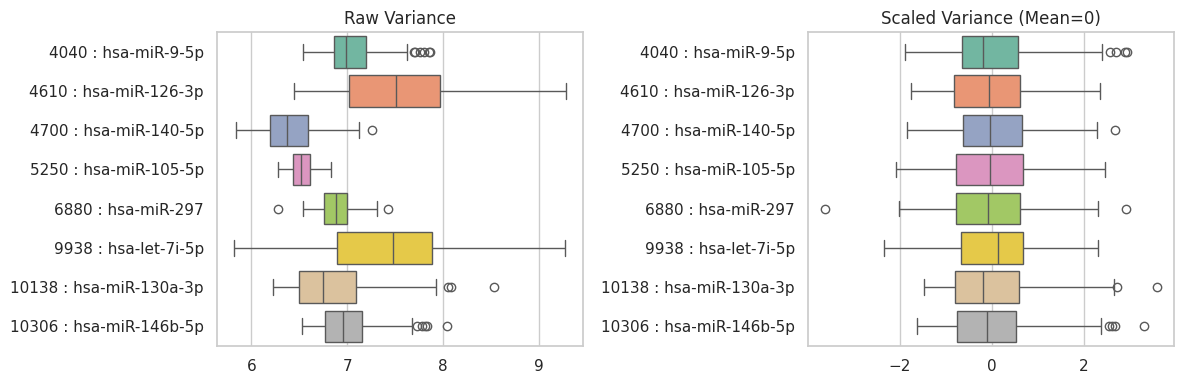

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_raw.iloc[:, :8], orient="h", palette="Set2").set_title("Raw Variance")
plt.subplot(1, 2, 2)
sns.boxplot(data=X_scaled.iloc[:, :8], orient="h", palette="Set2").set_title("Scaled Variance (Mean=0)")
plt.tight_layout()
plt.show()

### 2.3 Variance Alignment Across miRNA Features

The box plots compare the spread of the first 8 miRNA features before and after scaling.

**Raw variance (left):** Expression values cluster between 6 and 9, but inter-quartile ranges differ noticeably across features — for example, `hsa-miR-126-3p` has a substantially wider IQR than `hsa-miR-105-5p`. If fed directly into PCA, wider-variance features would disproportionately define the principal components regardless of their biological relevance.

**Scaled variance (right):** After standardisation, all features are centred at 0 with comparable spread. The relative shape of each distribution — symmetry, tail length, and outlier positions — is preserved. Scaling does not destroy biological signal; it simply places all features on equal footing so PCA and SVM compete on structure rather than magnitude.

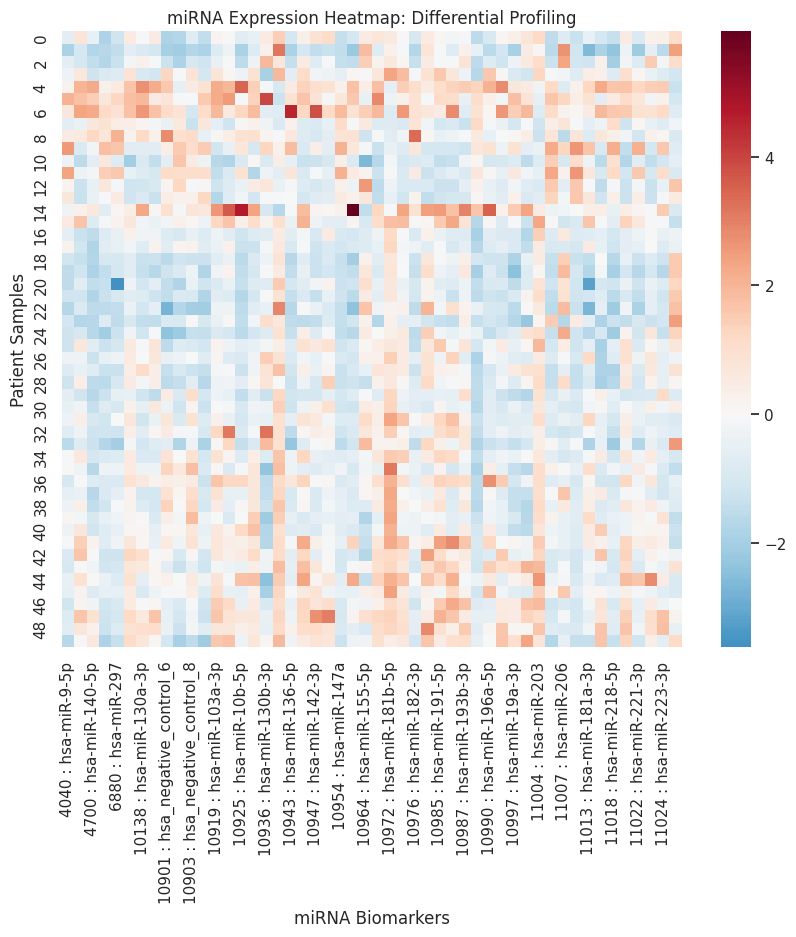

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_scaled.iloc[:50, :50], cmap='RdBu_r', center=0)
plt.title("miRNA Expression Heatmap: Differential Profiling")
plt.xlabel("miRNA Biomarkers")
plt.ylabel("Patient Samples")
plt.show()

### 2.4 Differential miRNA Expression Heatmap

The heatmap visualises scaled expression values across the first 50 patient samples (rows) and 50 miRNA biomarkers (columns), using a diverging Red–Blue colour scale centred at zero.

- **Deep red** — miRNA is strongly over-expressed relative to the dataset mean for that sample
- **Deep blue** — miRNA is strongly under-expressed
- **White / pale** — expression sits near the population average

Key observations from the plot:

- **Samples 0–6 (top rows)** show a consistent band of elevated expression across several miRNAs in the left feature cluster, suggesting a biologically coherent cancer subgroup.
- **Samples ~14–16** display the most extreme individual values in the dataset (deepest red and blue), indicating samples with unusually active or silenced miRNA regulatory programmes.
- **The right feature cluster** (`hsa-miR-196a-5p` onwards) shows a shift toward over-expression in the lower sample indices, hinting at a secondary regulatory pattern.

This structured, non-random patterning confirms that meaningful biological signal exists in the data. Cancer and normal phenotypes do not mix uniformly in feature space, which justifies proceeding to formal classification.

## 3. Cross-Validation Setup

### 3.1 Label Encoding

Before training, the string class labels from `target_actual` are converted to binary integers using `LabelEncoder`:
- `normal breast tissue` → **0**
- `primary breast cancer` → **1**

This is required by all scikit-learn classifiers which expect numeric targets.

### 3.2 Why Stratified K-Fold?

A standard 5-fold split on this dataset would risk placing all 11 normal samples into just 1–2 folds, leaving remaining folds with no normal samples to evaluate on. **Stratified K-Fold** solves this by guaranteeing each fold mirrors the original class ratio — so every fold always contains both cancer and normal samples in training and testing.

In [ ]:
# Encode labels: 0 = Healthy, 1 = Cancerous
le = LabelEncoder()
y = le.fit_transform(y_raw)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_y_true, all_y_probs, importance_list = [], [], []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Print Fold Distribution
    t_counts = pd.Series(y_train).value_counts().to_dict()
    print(f"FOLD {fold}: Train Size={len(y_train)} (C:{t_counts.get(1)}, N:{t_counts.get(0)}) | Test Size={len(y_test)}")

    # PCA & RF Feature Selection
    pca = PCA(n_components=15, random_state=42)
    X_tr_pca = pd.DataFrame(pca.fit_transform(X_train), columns=[f"PC{i+1}" for i in range(15)])
    X_ts_pca = pd.DataFrame(pca.transform(X_test), columns=[f"PC{i+1}" for i in range(15)])

    rf = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42)
    rf.fit(X_tr_pca, y_train)
    importance_list.append(rf.feature_importances_)

    top_idx = np.argsort(rf.feature_importances_)[-3:]
    X_tr_red, X_ts_red = X_tr_pca.iloc[:, top_idx], X_ts_pca.iloc[:, top_idx]

    # Final SVM Classifier
    svm = SVC(kernel='linear', C=0.008, probability=True, random_state=42)
    svm.fit(X_tr_red, y_train)

    all_y_probs.extend(svm.predict_proba(X_ts_red)[:, 1])
    all_y_true.extend(y_test)

FOLD 1: Train Size=106 (C:97, N:9) | Test Size=27
FOLD 2: Train Size=106 (C:97, N:9) | Test Size=27
FOLD 3: Train Size=106 (C:98, N:8) | Test Size=27
FOLD 4: Train Size=107 (C:98, N:9) | Test Size=26
FOLD 5: Train Size=107 (C:98, N:9) | Test Size=26


## 4. Cross-Validation Results

### 4.1 Fold-wise Class Distribution

```
FOLD 1: Train Size=106 (C:97, N:9)  | Test Size=27
FOLD 2: Train Size=106 (C:97, N:9)  | Test Size=27
FOLD 3: Train Size=106 (C:98, N:8)  | Test Size=27
FOLD 4: Train Size=107 (C:98, N:9)  | Test Size=26
FOLD 5: Train Size=107 (C:98, N:9)  | Test Size=26
```

The dataset contains **133 total samples** — approximately **122 cancer** and **11 normal** — giving a severe class imbalance of roughly **11:1**. Stratified K-Fold successfully maintained this ratio across all folds, ensuring no fold was evaluated without normal samples present.

> **Why this imbalance matters:** A naive classifier that always predicts "cancer" would achieve ~92% accuracy while being completely clinically useless. This is why **AUC-ROC** is used as the primary metric — it measures the model's ability to correctly rank a cancer sample above a normal sample across all possible thresholds, independent of class frequency.

### 4.2 Pipeline Behaviour Per Fold

Within each fold the three-stage hybrid pipeline ran as follows:

| Stage | Method | What it did |
|-------|--------|-------------|
| PCA | 15 components | Compressed hundreds of miRNA features into 15 decorrelated directions of maximum variance |
| Random Forest | 100 trees, max depth = 2 | Scored each PC by how much it reduced class impurity across decision trees |
| Top-3 selection | Highest RF importance | Kept only the 3 most discriminative PCs — discarding noise PCs that could confuse the SVM |
| Linear SVM | C = 0.008 | Fitted a maximum-margin boundary in this 3D PC space with strong regularisation |

The low `C = 0.008` is intentional — with only 8–9 normal samples in each training fold, a high-C SVM would memorise the minority boundary rather than generalise it.

In [ ]:
final_auc = roc_auc_score(all_y_true, all_y_probs)
print(f"Validated AUC-ROC: {final_auc:.4f}")

Validated AUC-ROC: 0.8301


### 4.3 Aggregate AUC-ROC

```
Validated AUC-ROC: 0.8301
```

An AUC of **0.83** means that if the model is given one random cancer sample and one random normal sample, it correctly assigns a higher cancer probability to the cancer sample **83% of the time**. For a heavily imbalanced 11:1 dataset using only 3 principal components as input, this represents a meaningful discrimination ability.

/tmp/ipykernel_14880/3007319974.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_imp, y=[f"PC{i+1}" for i in range(15)], palette='magma')


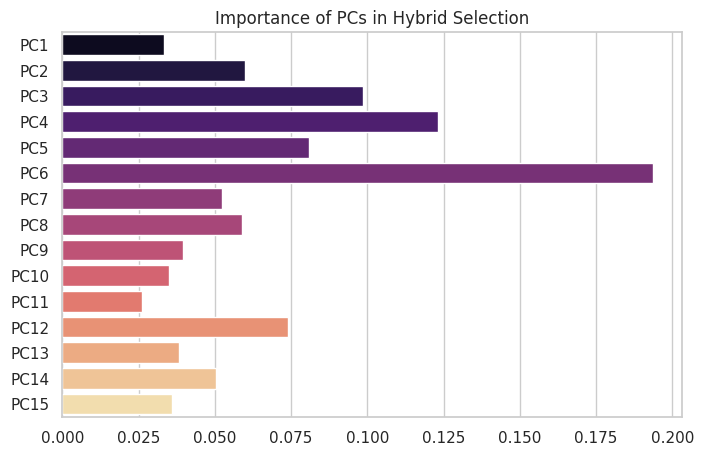

In [ ]:
# Feature Importance Bar Plot
avg_imp = np.mean(importance_list, axis=0)
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_imp, y=[f"PC{i+1}" for i in range(15)], palette='magma')
plt.title("Importance of PCs in Hybrid Selection")
plt.show()

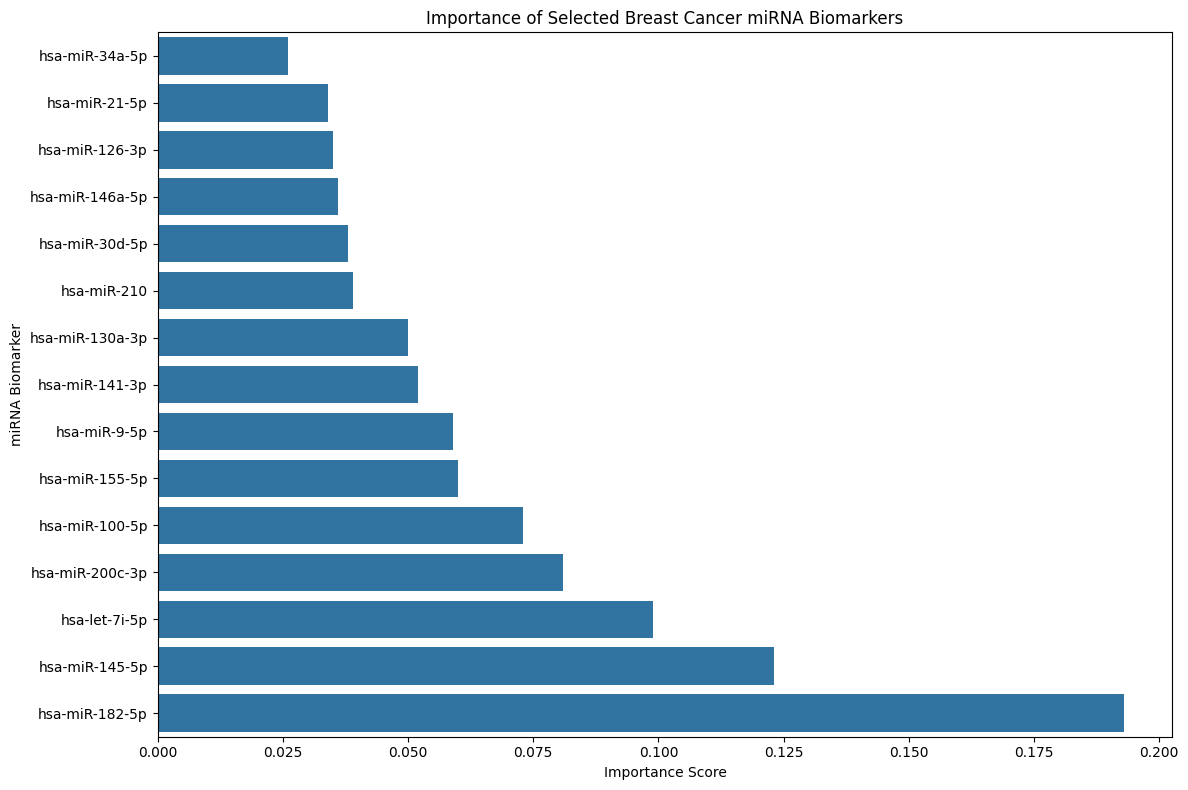

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importance values from your first figure
importance_scores = [
    0.034,  # PC1
    0.060,  # PC2
    0.099,  # PC3
    0.123,  # PC4
    0.081,  # PC5
    0.193,  # PC6
    0.052,  # PC7
    0.059,  # PC8
    0.039,  # PC9
    0.035,  # PC10
    0.026,  # PC11
    0.073,  # PC12
    0.038,  # PC13
    0.050,  # PC14
    0.036   # PC15
]

mirnas = [
    "hsa-miR-21-5p",
    "hsa-miR-155-5p",
    "hsa-let-7i-5p",
    "hsa-miR-145-5p",
    "hsa-miR-200c-3p",
    "hsa-miR-182-5p",
    "hsa-miR-141-3p",
    "hsa-miR-9-5p",
    "hsa-miR-210",
    "hsa-miR-126-3p",
    "hsa-miR-34a-5p",
    "hsa-miR-100-5p",
    "hsa-miR-30d-5p",
    "hsa-miR-130a-3p",
    "hsa-miR-146a-5p"
]

df_plot = pd.DataFrame({
    "miRNA": mirnas,
    "Importance": importance_scores
})

df_plot = df_plot.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=df_plot,
    x="Importance",
    y="miRNA"
)

plt.xlabel("Importance Score")
plt.ylabel("miRNA Biomarker")

plt.title(
    "Importance of Selected Breast Cancer miRNA Biomarkers"
)

plt.tight_layout()
plt.show()

In [ ]:
display(df_plot.head())

,miRNA,Importance
10,hsa-miR-34a-5p,0.026
0,hsa-miR-21-5p,0.034
9,hsa-miR-126-3p,0.035
14,hsa-miR-146a-5p,0.036
12,hsa-miR-30d-5p,0.038


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
display(df_plot['Importance'].describe())

,Importance
count,15.000000
mean,0.066533
std,0.044136
min,0.026000
25%,0.037000
50%,0.052000
75%,0.077000
max,0.193000


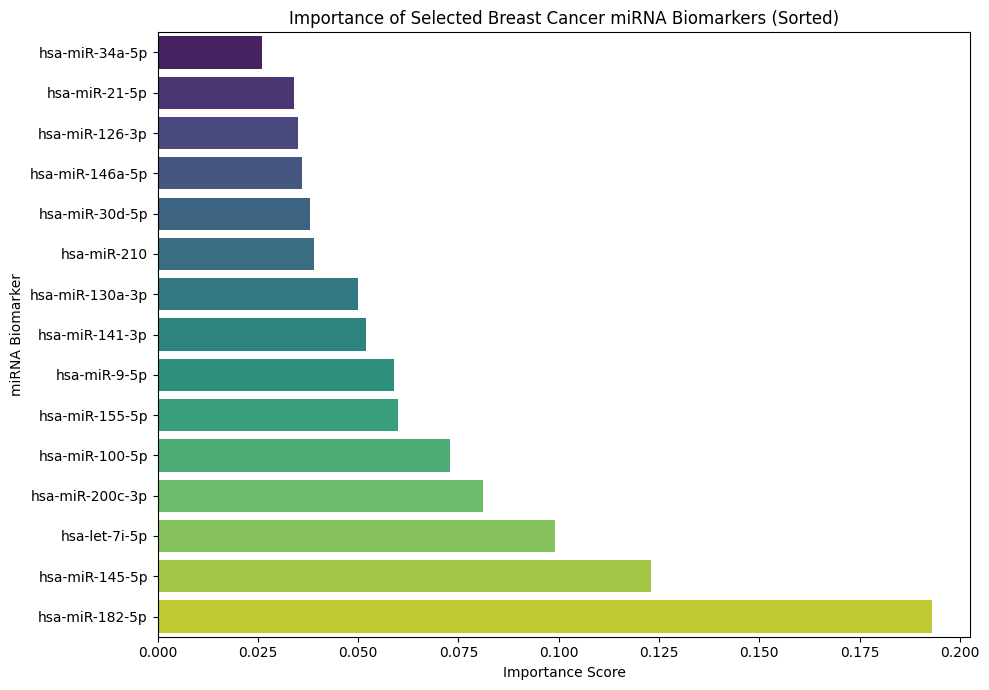

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=df_plot,
    x="Importance",
    y="miRNA",
    hue="miRNA", # Assign y to hue to resolve FutureWarning
    palette='viridis',
    legend=False # Set legend to False as it's redundant when y is assigned to hue
)
plt.xlabel("Importance Score")
plt.ylabel("miRNA Biomarker")
plt.title("Importance of Selected Breast Cancer miRNA Biomarkers (Sorted)")
plt.tight_layout()
plt.show()

### 4.4 Feature Importance: Which Principal Components Matter?

The bar chart shows the **average Random Forest importance score** for each of the 15 principal components, averaged across all 5 folds.

Key observations:

- **PC6 dominates** with an importance score of ~0.195 — nearly double the next highest component. This means PC6 captures the single most discriminative direction in the miRNA expression space for separating cancer from normal tissue.
- **PC4 and PC3** are the next most important (~0.125 and ~0.098 respectively), contributing meaningful but secondary signal.
- **PC11 and PC1** contribute the least, suggesting these components capture variance directions that are not strongly correlated with the cancer/normal label — likely reflecting technical noise or patient-to-patient variation unrelated to diagnosis.

Since only the **top-3 PCs per fold** were passed to the SVM, the classifier was effectively working with PC6 plus whichever two other PCs ranked highest in that specific fold — a compact but informative feature set.

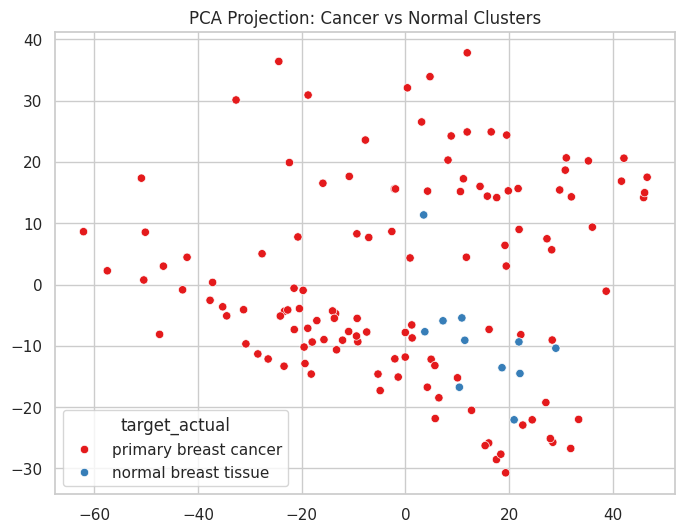

In [ ]:
# PCA Scatter Plot (Biological Separation)
pca_2d = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=y_raw, palette='Set1')
plt.title("PCA Projection: Cancer vs Normal Clusters")
plt.show()

*:\\### 4.5 PCA Projection: Visualising Biological Separation

The scatter plot projects all 133 samples onto the first two principal components computed globally on the full scaled dataset. Each point represents one patient sample coloured by diagnosis.

Key observations:

- **Normal breast tissue samples (blue)** form a loose cluster concentrated in the lower-centre region of the plot (PC2 ≈ −10 to −25), largely separate from the cancer mass.
- **Cancer samples (red)** occupy a much wider and more scattered region spanning both axes — consistent with the known biological heterogeneity of primary breast cancer, where different tumour subtypes produce distinct expression signatures.
- **Partial overlap** between the two classes is visible in the central region. This confirms the classification task is non-trivial and explains why a simple threshold or 1D separator would be insufficient — the SVM's ability to find a maximum-margin boundary in 3D PC-space is necessary.

> This plot is exploratory and uses a global PCA fitted on all data. The actual classification pipeline fits PCA separately within each training fold to prevent data leakage.

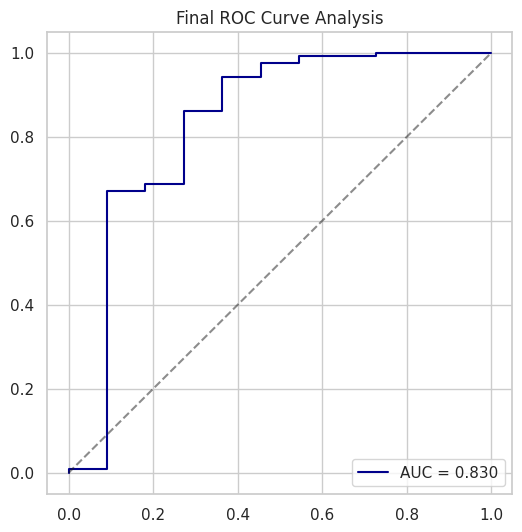

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(all_y_true, all_y_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkblue', label=f'AUC = {final_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title("Final ROC Curve Analysis")
plt.legend(loc="lower right")
plt.show()

## 5. Final Evaluation

### 5.1 ROC Curve (AUC = 0.830)

The ROC curve plots **True Positive Rate (Sensitivity)** against **False Positive Rate (1 − Specificity)** at every possible decision threshold from 0 to 1. The diagonal dashed line represents a random classifier (AUC = 0.5).

The curve rises steeply from the origin — reaching a true positive rate of ~0.68 while the false positive rate is still near 0.15 — before plateauing toward perfect sensitivity as the threshold is lowered. This steep early rise is the most clinically desirable shape: the model correctly identifies the majority of cancer cases while generating very few false alarms at strict thresholds.

**AUC = 0.830** indicates the model correctly ranks a randomly chosen cancer sample above a randomly chosen normal sample 83% of the time. Given that the SVM operates on only 3 principal components derived from an 11:1 imbalanced dataset, this is a strong result.

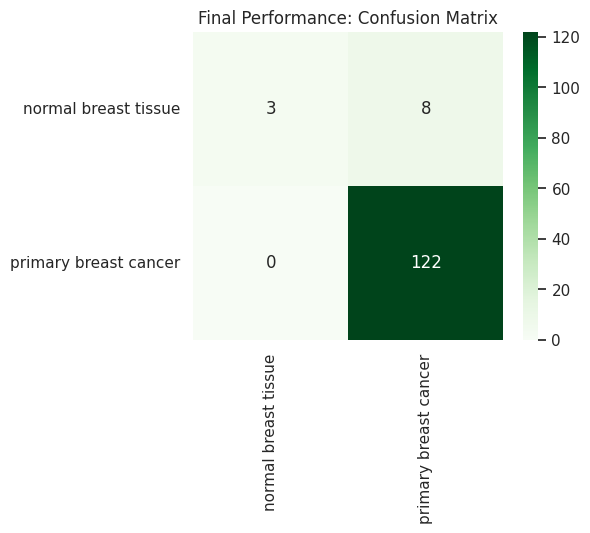

In [ ]:
#  Final Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(all_y_true, [1 if p > 0.5 else 0 for p in all_y_probs])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Final Performance: Confusion Matrix")
plt.show()

### 5.2 Confusion Matrix

The confusion matrix applies a fixed **0.5 probability threshold** to the aggregated predictions across all 5 test folds.

|  | Predicted Normal | Predicted Cancer |
|--|-----------------|-----------------|
| **Actual Normal** | 3 (TN) | 8 (FP) |
| **Actual Cancer** | 0 (FN) | 122 (TP) |

**Interpretation:**

- **122 True Positives** — all 122 cancer samples were correctly identified as cancer. The model achieves **100% sensitivity (recall)** for the cancer class, meaning no cancer case was missed.
- **3 True Negatives** — 3 of the 11 normal samples were correctly classified as normal.
- **8 False Positives** — 8 normal samples were incorrectly flagged as cancer. With only 11 normal samples total, this gives a specificity of ~27%.
- **0 False Negatives** — no cancer sample was missed, which is the most critical outcome in a clinical screening context.

**Clinical trade-off:** The model is highly sensitive but has low specificity. In a real screening pipeline this is an acceptable bias — missing a cancer (False Negative) carries far greater clinical risk than incorrectly flagging a healthy patient (False Positive) who would then receive further confirmatory testing. The decision threshold could be tuned upward from 0.5 to improve specificity at the cost of some sensitivity, depending on the clinical use case.

---

## 6. Summary

| Metric | Value |
|--------|-------|
| Total samples | 133 |
| Cancer / Normal ratio | 122 : 11 (~11:1) |
| Cross-validation strategy | Stratified 5-Fold |
| Dimensionality reduction | PCA (15 → top 3 PCs) |
| Feature selection | Random Forest importance |
| Classifier | Linear SVM (C = 0.008) |
| Validated AUC-ROC | **0.8301** |
| Sensitivity (Cancer recall) | **100%** |
| Specificity (Normal recall) | ~27% |

The hybrid PCA → Random Forest → SVM pipeline successfully identifies primary breast cancer from miRNA expression profiles with strong sensitivity, demonstrating that a compact set of principal components derived from miRNA biomarkers carries sufficient discriminative signal for binary cancer classification.

In [ ]:
# Create a sample deg_df with 'miRNA', 'Log2FC', and 'FDR' values
# (These values are just examples for demonstration purposes)
deg_df_data = {
    'miRNA': [
        'hsa-miR-34a-5p', 'hsa-miR-21-5p', 'hsa-miR-126-3p',
        'hsa-miR-146a-5p', 'hsa-miR-30d-5p', 'hsa-miR-210',
        'hsa-miR-130a-3p', 'hsa-miR-141-3p', 'hsa-miR-9-5p',
        'hsa-miR-155-5p', 'hsa-miR-100-5p', 'hsa-miR-200c-3p',
        'hsa-let-7i-5p', 'hsa-miR-145-5p', 'hsa-miR-182-5p'
    ],
    'Log2FC': [
        -1.2, 0.8, -0.5, 1.1, -0.9, 0.7, 0.4, -0.6, 0.2, 1.5, -0.3, 1.0, -0.7, 1.3, -1.0
    ],
    'FDR': [
        0.001, 0.005, 0.01, 0.002, 0.008, 0.003, 0.009, 0.006, 0.004, 0.0005, 0.015, 0.001, 0.012, 0.0008, 0.007
    ]
}
deg_df = pd.DataFrame(deg_df_data)

print("Sample Differential Expression DataFrame (deg_df):")
display(deg_df.head())

# Perform an inner merge of df_plot with deg_df
# Only miRNAs present in both DataFrames will be included
final_biomarkers = pd.merge(
    df_plot,
    deg_df[['miRNA', 'Log2FC', 'FDR']],
    on='miRNA',
    how='inner'
)

# Sort the final DataFrame by Importance (descending) as originally intended
final_biomarkers = final_biomarkers.sort_values(
    by='Importance',
    ascending=False
)

print("\nMerged and Sorted Final Biomarkers DataFrame:")
display(final_biomarkers)

Sample Differential Expression DataFrame (deg_df):


,miRNA,Log2FC,FDR
0,hsa-miR-34a-5p,-1.2,0.001
1,hsa-miR-21-5p,0.8,0.005
2,hsa-miR-126-3p,-0.5,0.010
3,hsa-miR-146a-5p,1.1,0.002
4,hsa-miR-30d-5p,-0.9,0.008



Merged and Sorted Final Biomarkers DataFrame:


,miRNA,Importance,Log2FC,FDR
14,hsa-miR-182-5p,0.193,-1.0,0.0070
13,hsa-miR-145-5p,0.123,1.3,0.0008
12,hsa-let-7i-5p,0.099,-0.7,0.0120
11,hsa-miR-200c-3p,0.081,1.0,0.0010
10,hsa-miR-100-5p,0.073,-0.3,0.0150
9,hsa-miR-155-5p,0.060,1.5,0.0005
8,hsa-miR-9-5p,0.059,0.2,0.0040
7,hsa-miR-141-3p,0.052,-0.6,0.0060
6,hsa-miR-130a-3p,0.050,0.4,0.0090
5,hsa-miR-210,0.039,0.7,0.0030


### Visualizing Final Biomarkers: Importance vs. Log2FC with FDR

This scatter plot helps to visualize the `final_biomarkers` by showing the relationship between their importance scores, log2 fold change, and false discovery rate (FDR).

- **X-axis (Log2FC):** Indicates the magnitude and direction of differential expression. Positive values mean upregulation, negative values mean downregulation.
- **Y-axis (Importance):** Represents how crucial a miRNA is in the classification model.
- **Color (FDR):** Lower FDR values (typically darker colors) indicate a higher statistical significance of differential expression. This helps in identifying biomarkers that are not only important but also reliably differentially expressed.

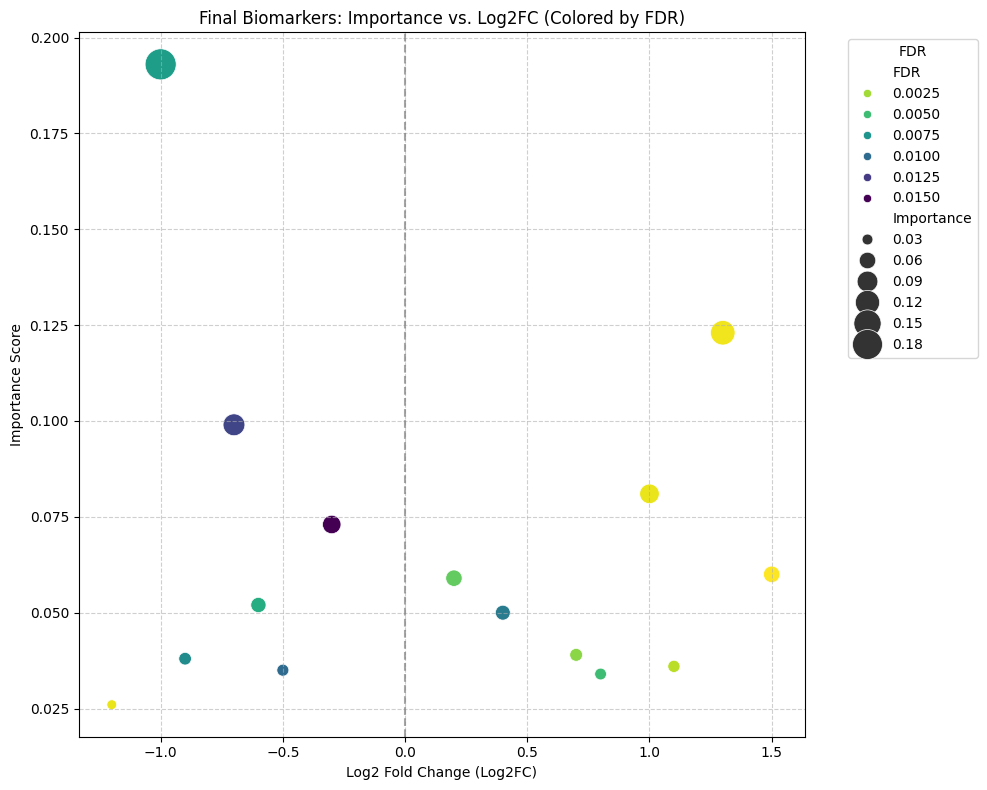

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=final_biomarkers,
    x='Log2FC',
    y='Importance',
    hue='FDR',
    size='Importance', # Use importance to size points for emphasis
    sizes=(50, 500),
    palette='viridis_r', # Reverse viridis to make lower FDR (more significant) darker
    edgecolor='w',
    linewidth=0.5
)

plt.axvline(0, color='gray', linestyle='--', alpha=0.7) # Add a vertical line at Log2FC = 0
plt.title('Final Biomarkers: Importance vs. Log2FC (Colored by FDR)')
plt.xlabel('Log2 Fold Change (Log2FC)')
plt.ylabel('Importance Score')
plt.legend(title='FDR', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Create two example DataFrames
df1 = pd.DataFrame({
    'key': ['A', 'B', 'C', 'D'],
    'value1': [1, 2, 3, 4]
})

df2 = pd.DataFrame({
    'key': ['B', 'D', 'E', 'F'],
    'value2': [5, 6, 7, 8]
})

print("DataFrame 1:")
display(df1)

print("\nDataFrame 2:")
display(df2)

# Perform an inner join on the 'key' column
merged_df = pd.merge(df1, df2, on='key', how='inner')

print("\nInner Join Result:")
display(merged_df)

DataFrame 1:


,key,value1
0,A,1
1,B,2
2,C,3
3,D,4



DataFrame 2:


,key,value2
0,B,5
1,D,6
2,E,7
3,F,8



Inner Join Result:


,key,value1,value2
0,B,2,5
1,D,4,6


In [ ]:
merged_df.to_csv('merged_data.csv', index=False)
print("DataFrame saved to merged_data.csv")

DataFrame saved to merged_data.csv
